# Análisis Exploratorio de Datos (EDA)

Exploraremos los datos limpios para comprender las relaciones entre las variables de supervivenia.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# Supervivencia por Género

C:\Users\ipadp\AppData\Local\Temp\ipykernel_14872\1505180528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


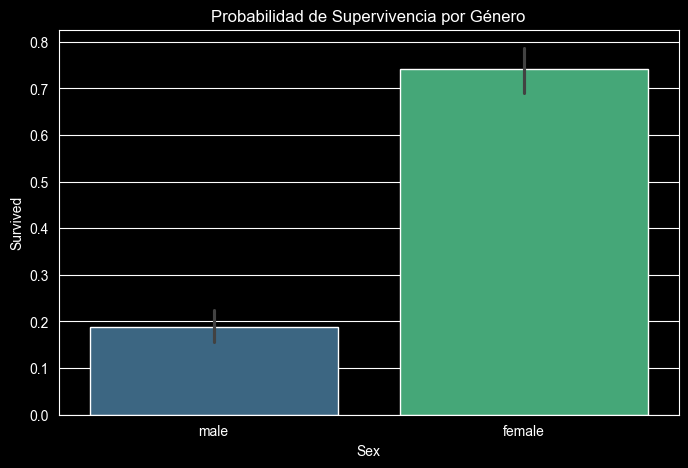

In [2]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

C:\Users\ipadp\AppData\Local\Temp\ipykernel_14872\3078854192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')


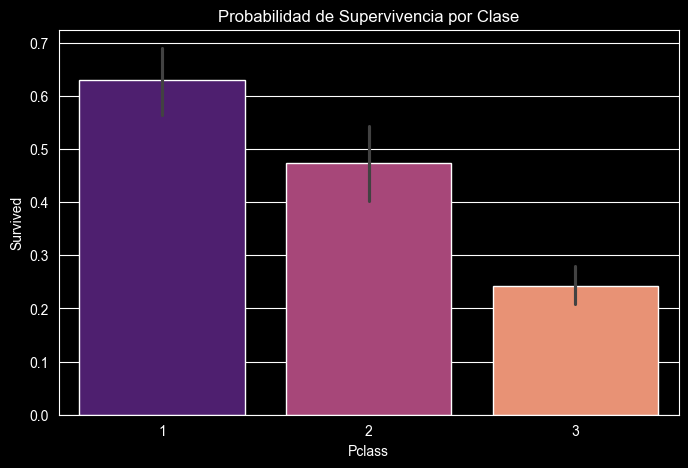

In [3]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de Edades

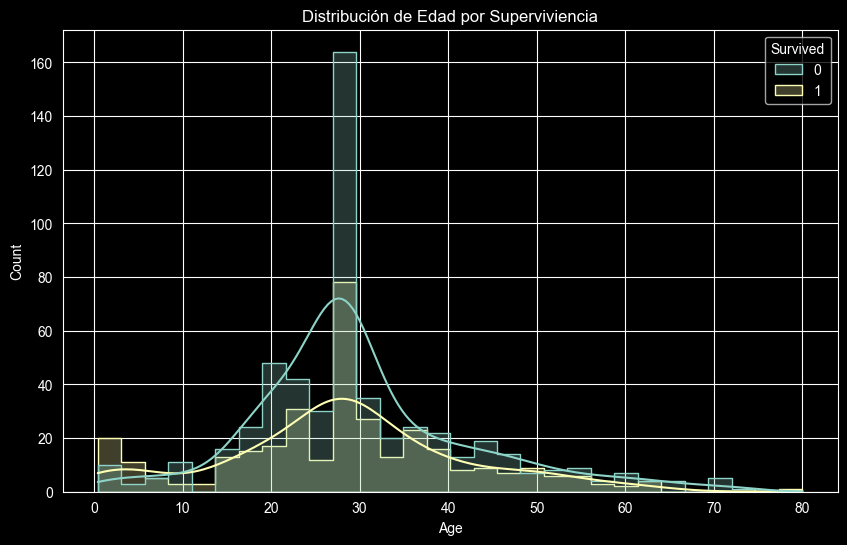

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

In [5]:
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})

df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


In [6]:
df.to_csv('data/titanic_feature.csv', index= False)

print("Datos guardados en data/titanic_feature.csv")

Datos guardados en data/titanic_feature.csv


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('data/titanic_feature.csv')

x = df.drop('Survived', axis=1)
y = df['Survived']



In [9]:
print(df.columns.tolist())
print(df.head())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Emb_C', 'Emb_Q', 'Emb_S']
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Emb_C  Emb_Q  Emb_S
0         0       3    0  22.0      1      0   7.2500  False  False   True
1         1       1    1  38.0      1      0  71.2833   True  False  False
2         1       3    1  26.0      0      0   7.9250  False  False   True
3         1       1    1  35.0      1      0  53.1000  False  False   True
4         0       3    0  35.0      0      0   8.0500  False  False   True


In [10]:
df['Embarked'] = df[['Emb_C', 'Emb_Q', 'Emb_S']].idxmax(axis=1)
df['Embarked'] = df['Embarked'].str.replace('Emb_', '')

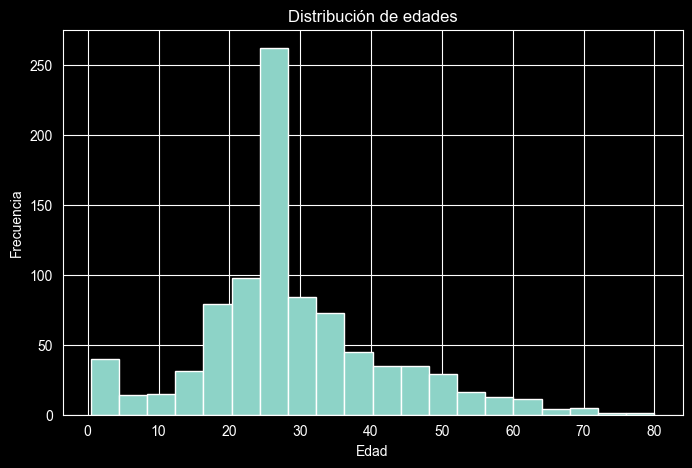

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=20)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

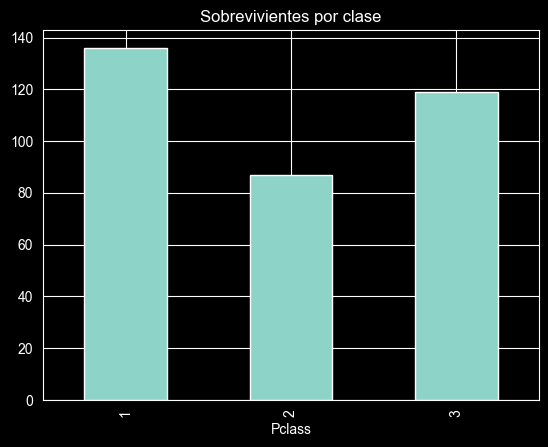

In [12]:
df.groupby('Pclass')['Survived'].sum().plot(kind='bar')
plt.title('Sobrevivientes por clase')
plt.show()

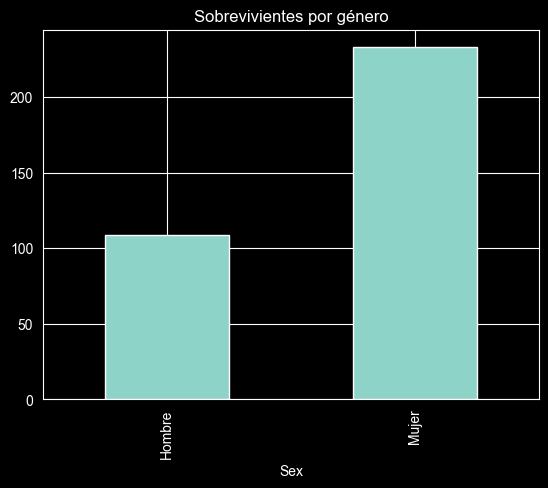

In [13]:
df.groupby('Sex')['Survived'].sum().plot(kind='bar')
plt.xticks([0,1],['Hombre','Mujer'])
plt.title('Sobrevivientes por género')
plt.show()

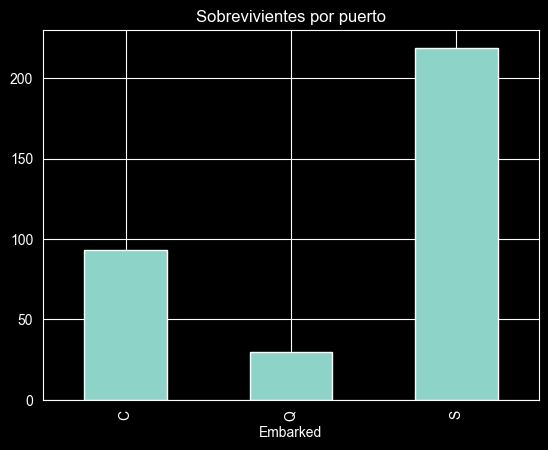

In [14]:
df.groupby('Embarked')['Survived'].sum().plot(kind='bar')
plt.title('Sobrevivientes por puerto')
plt.show()

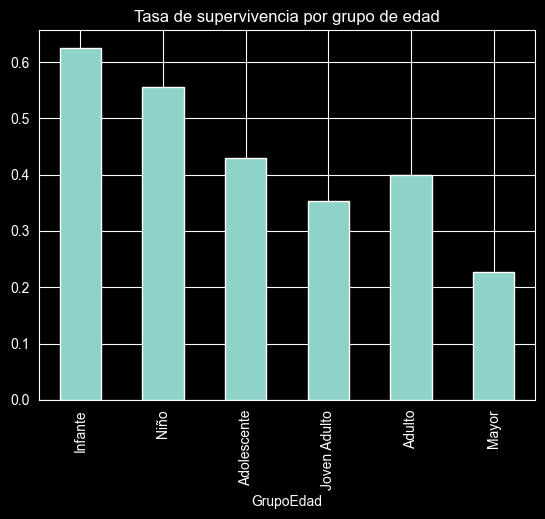

In [15]:
bins=[0,2,12,18,35,60,100]
labels=['Infante','Niño','Adolescente','Joven Adulto','Adulto','Mayor']

df['GrupoEdad']=pd.cut(df['Age'],bins=bins,labels=labels)

df.groupby('GrupoEdad')['Survived'].mean().plot(kind='bar')
plt.title('Tasa de supervivencia por grupo de edad')
plt.show()

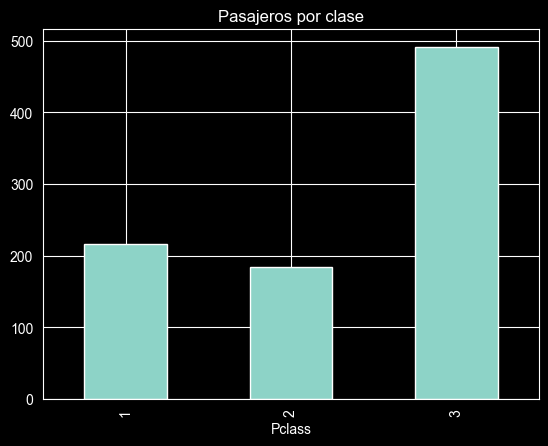

In [16]:
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Pasajeros por clase')
plt.show()

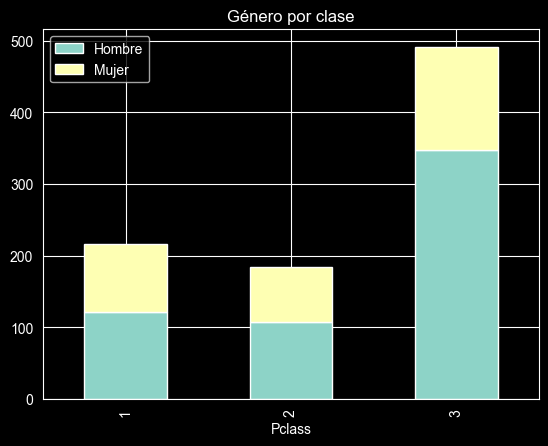

In [17]:
pd.crosstab(df['Pclass'],df['Sex']).plot(kind='bar',stacked=True)
plt.legend(['Hombre','Mujer'])
plt.title('Género por clase')
plt.show()

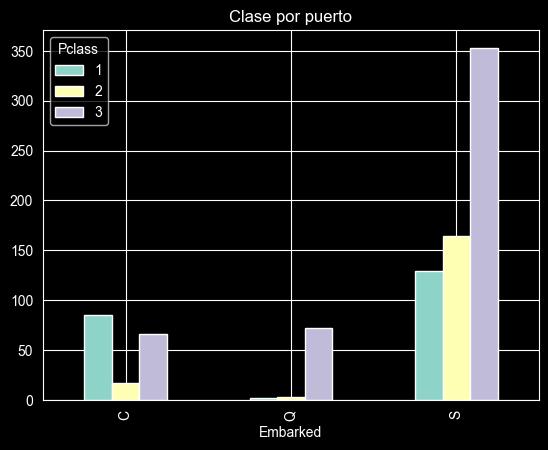

In [18]:
pd.crosstab(df['Embarked'],df['Pclass']).plot(kind='bar')
plt.title('Clase por puerto')
plt.show()

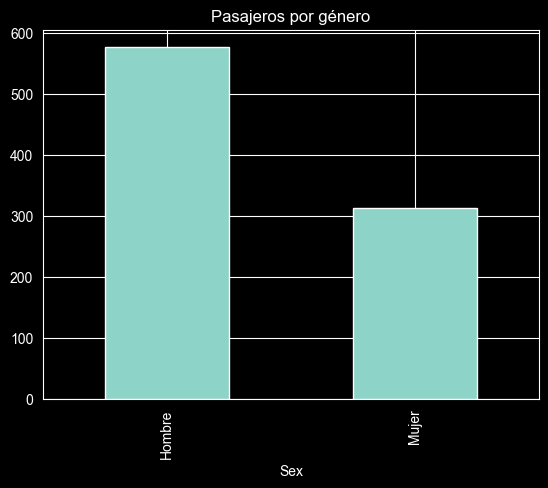

In [19]:
df['Sex'].value_counts().plot(kind='bar')
plt.xticks([0,1],['Hombre','Mujer'])
plt.title('Pasajeros por género')
plt.show()

In [20]:
print("Edad mínima:",df['Age'].min())
print("Edad máxima:",df['Age'].max())

Edad mínima: 0.42
Edad máxima: 80.0


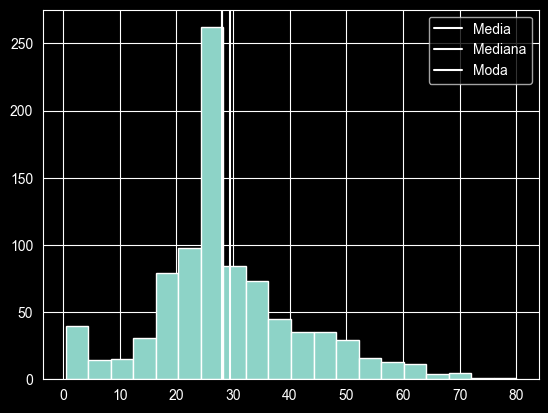

In [21]:
media=df['Age'].mean()
mediana=df['Age'].median()
moda=df['Age'].mode()[0]

plt.hist(df['Age'].dropna(),bins=20)

plt.axvline(media,label='Media')
plt.axvline(mediana,label='Mediana')
plt.axvline(moda,label='Moda')

plt.legend()
plt.show()

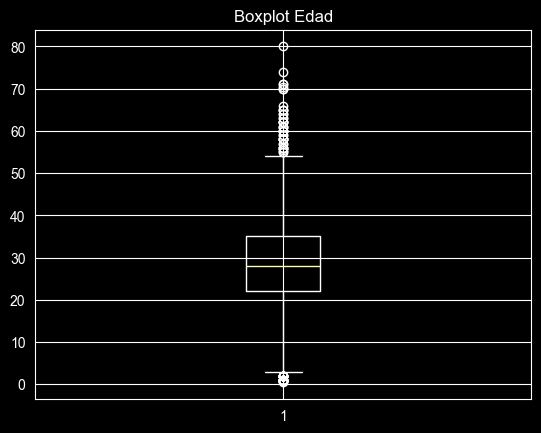

In [22]:
plt.boxplot(df['Age'].dropna())
plt.title('Boxplot Edad')
plt.show()

In [23]:
print("Fare mínimo:",df['Fare'].min())
print("Fare máximo:",df['Fare'].max())

Fare mínimo: 0.0
Fare máximo: 512.3292


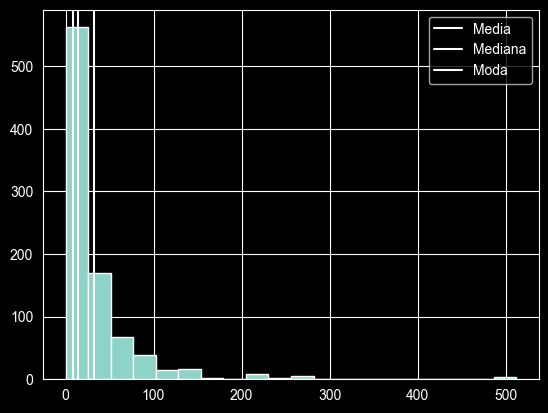

In [24]:
media=df['Fare'].mean()
mediana=df['Fare'].median()
moda=df['Fare'].mode()[0]

plt.hist(df['Fare'],bins=20)

plt.axvline(media,label='Media')
plt.axvline(mediana,label='Mediana')
plt.axvline(moda,label='Moda')

plt.legend()
plt.show()

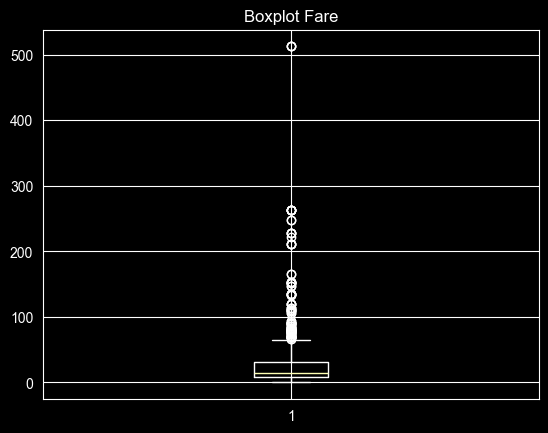

In [25]:
plt.boxplot(df['Fare'])
plt.title('Boxplot Fare')
plt.show()

In [26]:
df[df['Fare']==0]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S,Embarked,GrupoEdad
179,0,3,0,36.0,0,0,0.0,False,False,True,S,Adulto
263,0,1,0,40.0,0,0,0.0,False,False,True,S,Adulto
271,1,3,0,25.0,0,0,0.0,False,False,True,S,Joven Adulto
277,0,2,0,28.0,0,0,0.0,False,False,True,S,Joven Adulto
302,0,3,0,19.0,0,0,0.0,False,False,True,S,Joven Adulto
413,0,2,0,28.0,0,0,0.0,False,False,True,S,Joven Adulto
466,0,2,0,28.0,0,0,0.0,False,False,True,S,Joven Adulto
481,0,2,0,28.0,0,0,0.0,False,False,True,S,Joven Adulto
597,0,3,0,49.0,0,0,0.0,False,False,True,S,Adulto
633,0,1,0,28.0,0,0,0.0,False,False,True,S,Joven Adulto


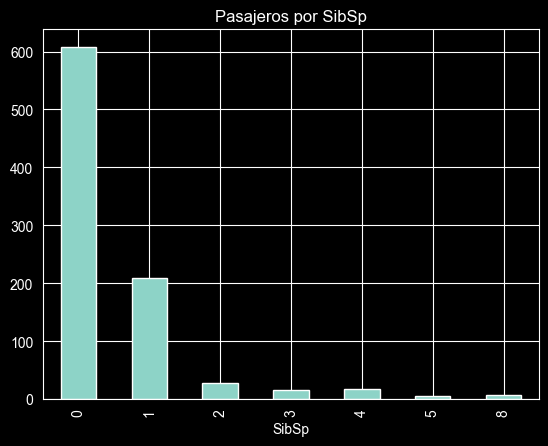

In [27]:
df['SibSp'].value_counts().sort_index().plot(kind='bar')
plt.title('Pasajeros por SibSp')
plt.show()

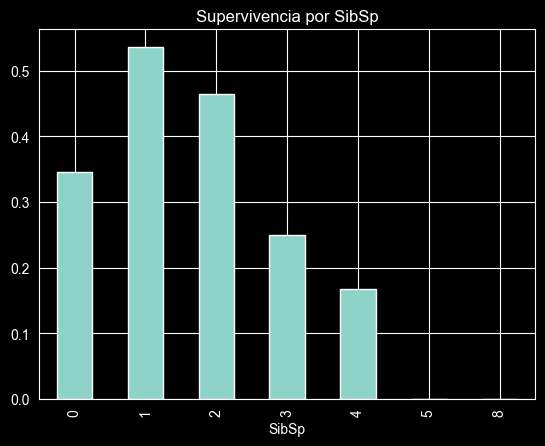

In [28]:
df.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.title('Supervivencia por SibSp')
plt.show()

In [29]:
porcentaje=df.groupby('SibSp')['Survived'].mean()*100
print(porcentaje)

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64


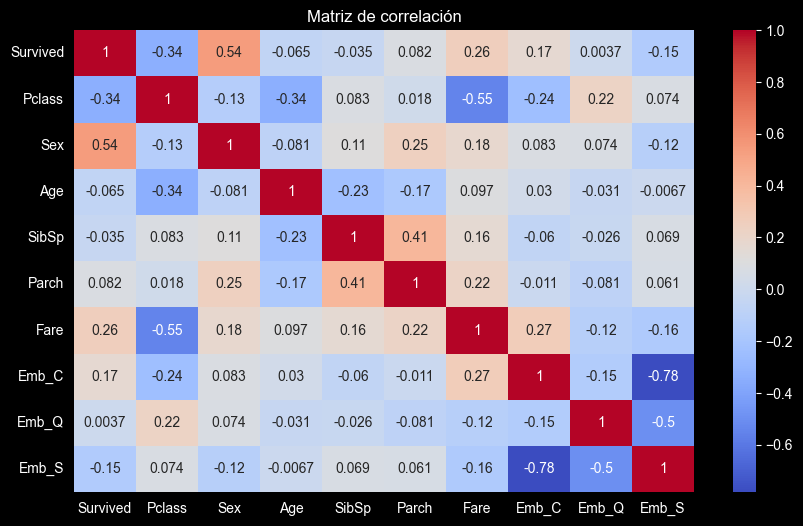

In [30]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Matriz de correlación')
plt.show()